In [253]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBClassifier

In [223]:
df = pd.read_csv('../../dataset.csv')
df.head()

,Year,Quarter,Date,Ticker,Open,Close,High,Low,Volume,Revenues,...,BollingerBandWidth,ATR,FiveDStdDev,OBV,MFI,VolumeRatio,GrossMargin,NetMargin,RoA,RevGrowthQoQ
0,2016,Q1,2016-03-28 00:00:00-04:00,CRM,71.521001,71.086281,71.807521,70.552770,2688100,1.916603e+09,...,NaN,NaN,NaN,0,NaN,1.089821,0.741,0.020,0.003,NaN
1,2016,Q1,2016-03-29 00:00:00-04:00,CRM,70.681204,71.432083,71.817401,69.861166,4606100,1.916603e+09,...,NaN,NaN,NaN,4606100,NaN,1.089821,0.741,0.020,0.003,0.0
2,2016,Q1,2016-03-30 00:00:00-04:00,CRM,72.123676,73.408073,73.763752,72.084155,5181100,1.916603e+09,...,NaN,NaN,NaN,9787200,NaN,1.089821,0.741,0.020,0.003,0.0
3,2016,Q1,2016-03-31 00:00:00-04:00,CRM,73.170953,72.943718,73.496993,72.499115,4226900,1.916603e+09,...,NaN,NaN,NaN,5560300,NaN,1.089821,0.741,0.020,0.003,0.0
4,2016,Q2,2016-04-01 00:00:00-04:00,CRM,72.499112,74.820908,75.038260,72.232356,4550600,2.036618e+09,...,NaN,1.869287,NaN,10110900,52.955228,1.089821,0.742,0.113,0.016,NaN


In [224]:
df[df['Year'] == 2024].shape[0]

7255

In [225]:
df = pd.read_csv('/Users/mac/Coding-Projects/ml-weekend-gap-prediction/structured_csv_data_files/aggregated/final_dataset.csv')
df.head()

,Ticker,Friday_Date,Target_Direction,Four_Day_Momentum,Friday_Momentum,Weekly_Drawdown,Friday_Drawdown,Weekly_Bounce,Friday_Bounce,Four_Day_Volume,...,CostOfRevenues,GrossProfit,NetIncome,Assets,Equity,Shares,GrossMargin,NetMargin,RoA,RevGrowthQoQ
0,ADBE,2016-08-12,0,0.023605,0.000594,0.008731,0.001581,0.026099,0.009794,7644200,...,202701000.0,1.261266e+09,270788000.0,12367441000,7.277946e+09,497025000.0,0.862,0.185,0.022,0.0
1,ADBE,2016-08-19,0,-0.001990,0.000100,0.006438,0.002882,0.008748,0.006017,7388100,...,202701000.0,1.261266e+09,270788000.0,12367441000,7.277946e+09,497025000.0,0.862,0.185,0.022,0.0
2,ADBE,2016-08-26,0,0.015927,0.003737,0.006715,0.006715,0.018156,0.009695,5442400,...,202701000.0,1.261266e+09,270788000.0,12367441000,7.277946e+09,497025000.0,0.862,0.185,0.022,0.0
3,ADBE,2016-09-02,0,0.014497,0.000773,0.005664,0.005664,0.020294,0.006022,6824000,...,202701000.0,1.261266e+09,270788000.0,12367441000,7.277946e+09,497025000.0,0.862,0.185,0.022,0.0
4,ADBE,2016-09-09,0,-0.038227,-0.015747,0.042028,0.018760,0.000000,0.000000,8461500,...,202701000.0,1.261266e+09,270788000.0,12367441000,7.277946e+09,497025000.0,0.862,0.185,0.022,0.0


In [226]:
X = df.drop(['Target_Direction','Ticker', 'Friday_Date'], axis=1)
y = df['Target_Direction']

In [227]:
y.head(50)

0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     1
10    0
11    0
12    0
13    1
14    0
15    0
16    0
17    1
18    0
19    0
20    0
21    0
22    0
23    0
24    1
25    0
26    1
27    1
28    1
29    1
30    0
31    1
32    1
33    1
34    1
35    1
36    1
37    1
38    1
39    1
40    1
41    1
42    0
43    1
44    1
45    0
46    0
47    1
48    0
49    0
Name: Target_Direction, dtype: int64

In [228]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [229]:
X['Friday_Date'] = df['Friday_Date']

In [230]:
X.head()

,Four_Day_Momentum,Friday_Momentum,Weekly_Drawdown,Friday_Drawdown,Weekly_Bounce,Friday_Bounce,Four_Day_Volume,Friday_Volume,Friday_Volume_Concentration,RSI,...,GrossProfit,NetIncome,Assets,Equity,Shares,GrossMargin,NetMargin,RoA,RevGrowthQoQ,Friday_Date
0,0.023605,0.000594,0.008731,0.001581,0.026099,0.009794,7644200,1713300,0.224131,72.935777,...,1.261266e+09,270788000.0,12367441000,7.277946e+09,497025000.0,0.862,0.185,0.022,0.0,2016-08-12
1,-0.001990,0.000100,0.006438,0.002882,0.008748,0.006017,7388100,1587900,0.214927,36.466161,...,1.261266e+09,270788000.0,12367441000,7.277946e+09,497025000.0,0.862,0.185,0.022,0.0,2016-08-19
2,0.015927,0.003737,0.006715,0.006715,0.018156,0.009695,5442400,1834600,0.337094,95.789381,...,1.261266e+09,270788000.0,12367441000,7.277946e+09,497025000.0,0.862,0.185,0.022,0.0,2016-08-26
3,0.014497,0.000773,0.005664,0.005664,0.020294,0.006022,6824000,1719300,0.251949,85.781901,...,1.261266e+09,270788000.0,12367441000,7.277946e+09,497025000.0,0.862,0.185,0.022,0.0,2016-09-02
4,-0.038227,-0.015747,0.042028,0.018760,0.000000,0.000000,8461500,3379300,0.399374,13.785969,...,1.261266e+09,270788000.0,12367441000,7.277946e+09,497025000.0,0.862,0.185,0.022,0.0,2016-09-09


Number of features before PCA

In [231]:
X.shape[1]

39

In [232]:
finals = {}

Baseline

In [247]:
pca = PCA(n_components=38)
X_pca = pca.fit_transform(X_scaled)
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.3, random_state=42, shuffle=False) 
model = LogisticRegression(max_iter=1000000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
 

In [248]:
acc

0.466875

Baseline Average: 0.466875

PCA Experiment

In [ ]:
for i in range(1, 39):
    pca = PCA(n_components=i)
    X_pca = pca.fit_transform(X_scaled)
    X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.3, random_state=42, shuffle=False) 
    model = LogisticRegression(solver='saga', penalty='elasticnet', l1_ratio=0.1, max_iter=10000)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    finals[i] = acc  

/opt/anaconda3/envs/FAI/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/anaconda3/envs/FAI/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/anaconda3/envs/FAI/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid 

In [265]:
print("Best Accuracy:", max(finals.values()), "with", max(finals, key=finals.get), "components")

Best Accuracy: 0.468125 with 34 components


PCA Best: 0.4685416666666667 with 34 components

In [251]:
print(((0.4685416666666667-0.466875) / 0.466875) * 100)

0.35698348951361825


0.35% improvement using PCA

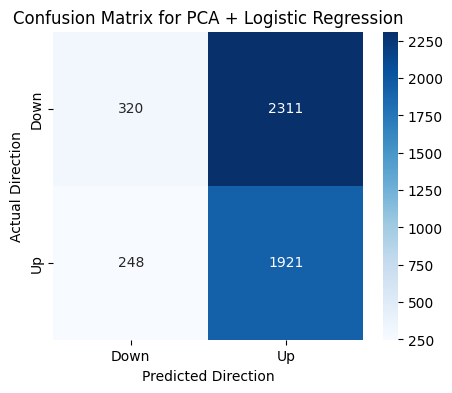

In [237]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Down', 'Up'], yticklabels=['Down', 'Up'])
plt.xlabel('Predicted Direction')
plt.ylabel('Actual Direction')
plt.title('Confusion Matrix for PCA + Logistic Regression')
plt.show()

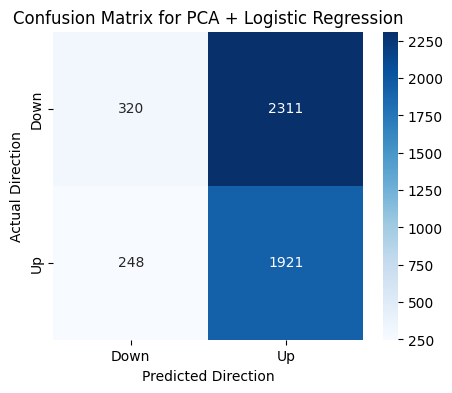

In [238]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Down', 'Up'], yticklabels=['Down', 'Up'])
plt.xlabel('Predicted Direction')
plt.ylabel('Actual Direction')
plt.title('Confusion Matrix for PCA + Logistic Regression')
plt.show()

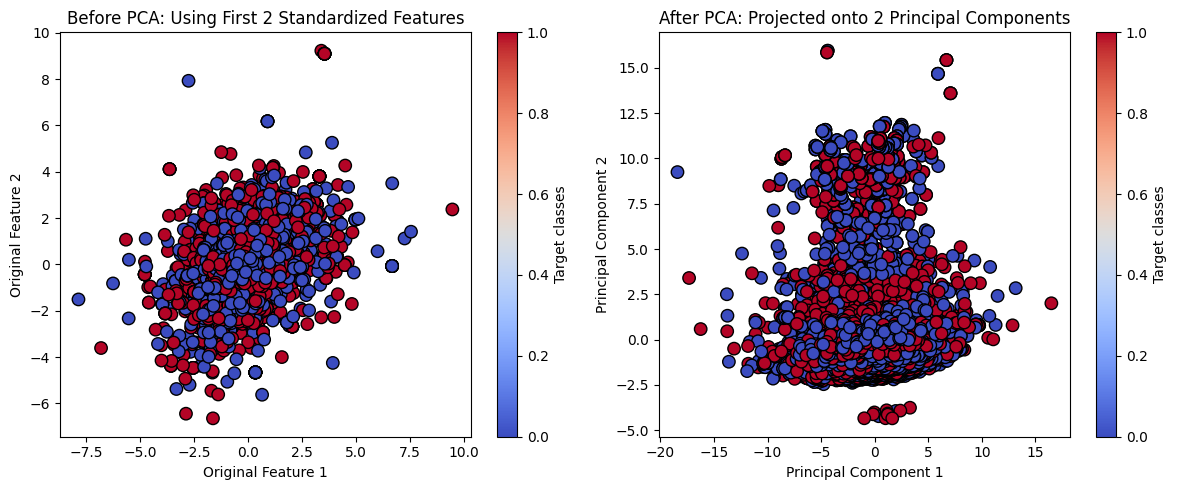

In [239]:
y_numeric = pd.factorize(y)[0]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_numeric, cmap='coolwarm', edgecolor='k', s=80)
plt.xlabel('Original Feature 1')
plt.ylabel('Original Feature 2')
plt.title('Before PCA: Using First 2 Standardized Features')
plt.colorbar(label='Target classes')

plt.subplot(1, 2, 2)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_numeric, cmap='coolwarm', edgecolor='k', s=80)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('After PCA: Projected onto 2 Principal Components')
plt.colorbar(label='Target classes')

plt.tight_layout()
plt.show()

Same experiment but this time with walk forward validation

In [268]:
tscv = TimeSeriesSplit(n_splits=18)

In [269]:
accuracies = []

In [270]:
finals = {}

In [271]:
model = LogisticRegression(solver='saga', penalty='elasticnet', l1_ratio=0.1, max_iter=10000)

In [272]:
for i in range(2,39):
    for fold, (train_index, test_index) in enumerate(tscv.split(X), start=1):
        pca = PCA(n_components=i)
        X_pca = pca.fit_transform(X_scaled)
        # Slice the data chronologically using the indices
        X_train, X_test = X_pca[train_index], X_pca[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]
        
        # Fit the pipeline (PCA + LogReg) entirely on the PAST data
        model.fit(X_train, y_train)
        
        # Predict the unseen FUTURE data
        predictions = model.predict(X_test)
        
        # Evaluate performance for this specific slice of time
        acc = accuracy_score(y_test, predictions)
        accuracies.append(acc)
    finals[i] = np.mean(accuracies)

/opt/anaconda3/envs/FAI/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/anaconda3/envs/FAI/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/anaconda3/envs/FAI/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid 

Baseline Average Walk-Forward Accuracy: 0.4783

In [273]:
print("Best Accuracy:", max(finals.values()), "with", max(finals, key=finals.get), "components")

Best Accuracy: 0.5101609923462656 with 2 components


PCA 2(Best) - Average Walk-Forward Accuracy: 0.5101609923462656

In [245]:
print(((0.51-0.4783) / 0.4783) * 100)

6.627639556763539


Conclusion: 6.7% improvement in accuracy using PCA

XGBoost

In [258]:
xgb_model = XGBClassifier(
    n_estimators=1000,        
    learning_rate=0.05,       
    early_stopping_rounds=20, 
    random_state=42,
    eval_metric='logloss'     
)

In [259]:
for i in range(2,39):
    for fold, (train_index, test_index) in enumerate(tscv.split(X), start=1):
        pca = PCA(n_components=i)
        X_pca = pca.fit_transform(X_scaled)
        # Slice the data chronologically using the indices
        X_train, X_test = X_pca[train_index], X_pca[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]
        
        # Fit the pipeline (PCA + LogReg) entirely on the PAST data
        model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=100,
        )
        
        # Predict the unseen FUTURE data
        predictions = model.predict(X_test)
        
        # Evaluate performance for this specific slice of time
        acc = accuracy_score(y_test, predictions)
        accuracies.append(acc)
    finals[i] = np.mean(accuracies)

[0]	validation_0-logloss:0.71714
[100]	validation_0-logloss:0.69070
[106]	validation_0-logloss:0.69194
[0]	validation_0-logloss:0.64688
[34]	validation_0-logloss:0.65387
[0]	validation_0-logloss:0.70308
[100]	validation_0-logloss:0.70112
[133]	validation_0-logloss:0.70173
[0]	validation_0-logloss:0.72590
[100]	validation_0-logloss:0.72011
[155]	validation_0-logloss:0.71987
[0]	validation_0-logloss:0.71684
[100]	validation_0-logloss:0.71375
[167]	validation_0-logloss:0.71302
[0]	validation_0-logloss:0.70812
[43]	validation_0-logloss:0.70841
[0]	validation_0-logloss:0.70111
[31]	validation_0-logloss:0.70344
[0]	validation_0-logloss:0.67210
[30]	validation_0-logloss:0.67550
[0]	validation_0-logloss:0.68702
[30]	validation_0-logloss:0.68728
[0]	validation_0-logloss:0.69433
[34]	validation_0-logloss:0.69692
[0]	validation_0-logloss:0.67402
[100]	validation_0-logloss:0.66925
[166]	validation_0-logloss:0.66858
[0]	validation_0-logloss:0.69639
[85]	validation_0-logloss:0.69573
[0]	validation_0

In [260]:
print("Best Accuracy:", max(finals.values()), "with", max(finals, key=finals.get), "components")

Best Accuracy: 0.5056202283043139 with 38 components
